# Logistic Regression Baseline: Clinical Interpretability
This notebook establishes the **Logistic Regression** baseline for the Sarcopenic Obesity (SO) study. 

### Objectives:
1. **Baseline Metrics**: Evaluate classification performance (AUC-ROC, PR-AUC) using a linear model.
2. **Odds Ratios**: Interpret the clinical impact of biochemical and anthropometric markers.
3. **Comparison Reference**: Provide a benchmark for more complex ensamble models (XGBoost, etc.).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix, 
    accuracy_score, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Paths relative to the project root
DATA_DIR = Path("../../data")
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

In [7]:
def clean_numeric(series):
    if series.dtype != object: return pd.to_numeric(series, errors='coerce')
    return pd.to_numeric(series.astype(str).str.replace(',', '.', regex=False).str.strip(), errors='coerce')

def calculate_metrics_and_or(search, X_test, y_test, feature_names, target_name):
    """Calculates performance and clinical Odds Ratios."""
    y_prob = search.predict_proba(X_test)[:, 1]
    y_pred = search.predict(X_test)
    
    # 1. Performance Summary
    metrics = {
        'ROC_AUC': roc_auc_score(y_test, y_prob),
        'PR_AUC': average_precision_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred)
    }
    
    # 2. Extract Coefficients for Odds Ratios (OR = exp(coef))
    model = search.named_steps['model']
    coeffs = model.coef_[0]
    ors = np.exp(coeffs)
    
    or_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coeffs,
        'Odds_Ratio': ors
    }).sort_values(by='Odds_Ratio', ascending=False)
    
    return metrics, or_df

In [8]:
def apply_definitions(df):
    """Consolidated diagnostic logic."""
    sex_idx = (df['SEXO'] == 1).astype(int)
    height_m = df['HEIGHT_FINAL'] / 100.0
    
    # ASM (Lee et al.) & ASMI
    df['ASM'] = (0.244 * df['WEIGHT_FINAL']) + (7.8 * height_m) + (6.6 * sex_idx) - (0.098 * df['EDAD']) - 3.3
    df['ASMI'] = df['ASM'] / (height_m ** 2)
    df['BMI'] = df['WEIGHT_FINAL'] / (height_m ** 2)
    
    # ESPEN/EASO 2022 - BFP (Gallagher 2000)
    df['BFP'] = (1.20 * df['BMI']) + (0.23 * df['EDAD']) - (10.8 * sex_idx) - 5.4
    
    # Simple Proxy SO
    cc_proxy = ((df['SEXO'] == 1) & (df['CIRCPANTORRILLA19_1'] < 34)) | ((df['SEXO'] == 2) & (df['CIRCPANTORRILLA19_1'] < 33))
    df['SO_SIMP_1'] = ((df['BMI'] >= 30) & cc_proxy).astype(float)
    # Handle missing values to avoid false negatives (Target Leakage Fix)
    df.loc[df['BMI'].isna() | df['CIRCPANTORRILLA19_1'].isna(), 'SO_SIMP_1'] = np.nan
    
    # ESPEN/EASO SO
    high_bfp = ((df['SEXO'] == 1) & (df['BFP'] > 25)) | ((df['SEXO'] == 2) & (df['BFP'] > 35))
    low_asmi = ((df['SEXO'] == 1) & (df['ASMI'] < 7.0)) | ((df['SEXO'] == 2) & (df['ASMI'] < 5.7))
    df['SO_ESPEN'] = (high_bfp & low_asmi).astype(float)
    # Handle missing values to avoid false negatives
    df.loc[df['BFP'].isna() | df['ASMI'].isna(), 'SO_ESPEN'] = np.nan
    
    return df


Evaluating Baseline for: SO_SIMP_1
  Features used: 11 predictors
  ROC-AUC: 0.778 | PR-AUC: 0.073

Evaluating Baseline for: SO_ESPEN
  Features used: 9 predictors
  ROC-AUC: 0.947 | PR-AUC: 0.247


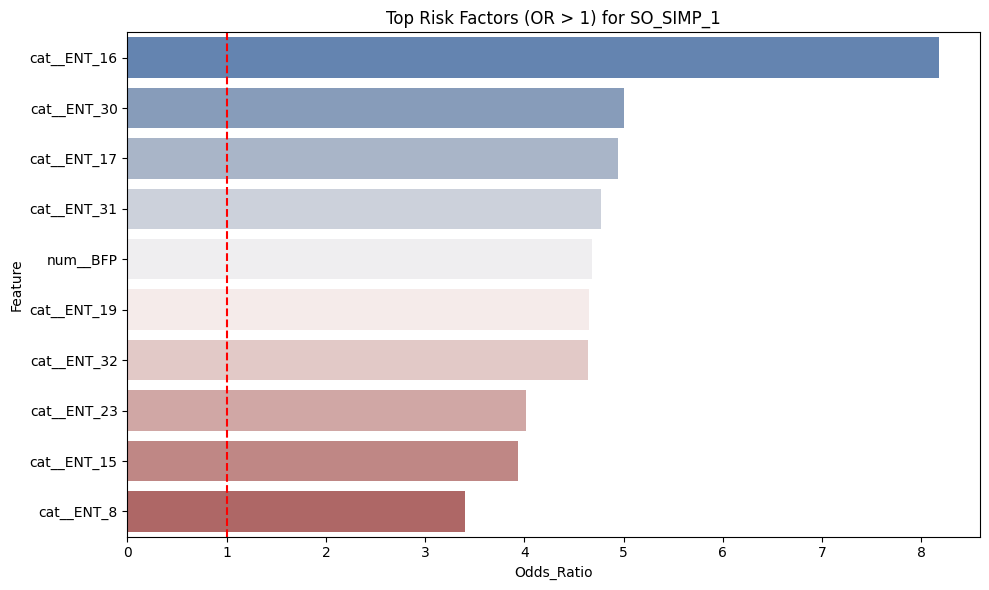

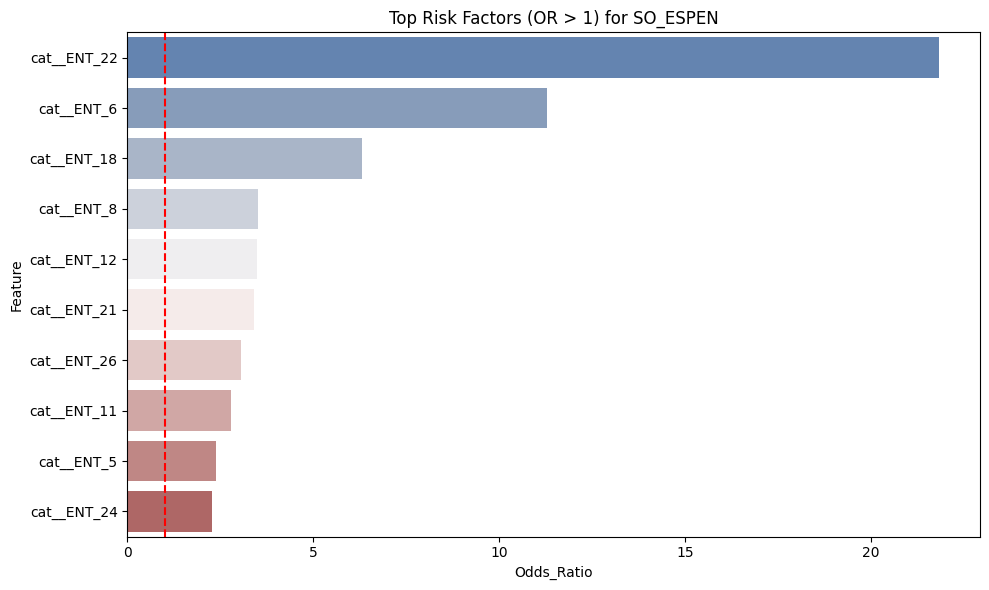


✅ Logistic Regression results saved to results/


In [9]:
# Load data
df = pd.read_csv(DATA_DIR / "ensanut_integrated.csv", low_memory=False)
df.columns = [c.upper() for c in df.columns]

# Clean numeric variables
cols = ['WEIGHT_FINAL', 'HEIGHT_FINAL', 'SEXO', 'EDAD', 'CINTURA21_1', 'CIRCPANTORRILLA19_1', 'CRP', 'FERRITINA', 'HCST', 'VIT_B12', 'VIT_D', 'ENT', 'REGION']
for col in cols:
    if col in df.columns: df[col] = clean_numeric(df[col])

# Analytic Population Filter
df = df[df['EDAD'] >= 20].copy()
if 'P8_9' in df.columns:
    df['P8_9'] = clean_numeric(df['P8_9'])
    df = df[~((df['SEXO'] == 2) & (df['P8_9'] == 1))].copy()

df = df.dropna(subset=['WEIGHT_FINAL', 'HEIGHT_FINAL', 'SEXO', 'EDAD']).copy()
df = apply_definitions(df)

# Preprocessing setup & Candidate Features
candidate_numeric_features = [
    'EDAD', 'BMI', 'CINTURA21_1', 'CIRCPANTORRILLA19_1', 'CRP', 
    'FERRITINA', 'HCST', 'VIT_B12', 'VIT_D', 'WEIGHT_FINAL', 
    'HEIGHT_FINAL', 'BFP', 'ASMI'
]

candidate_categorical_features = [
    'SEXO', 'ENT', 'REGION'
]

# Strict target leakage exclusions per outcome
leakage_exclusions = {
    'SO_SIMP_1': {
        'BMI', 'CIRCPANTORRILLA19_1', 'SEXO', 'WEIGHT_FINAL', 'HEIGHT_FINAL'
    },
    'SO_ESPEN': {
        'BMI', 'BFP', 'ASMI', 'WEIGHT_FINAL', 'HEIGHT_FINAL', 'EDAD', 'SEXO'
    }
}

targets = ['SO_SIMP_1', 'SO_ESPEN']
all_baseline_results = []

for target in targets:
    print(f"\nEvaluating Baseline for: {target}")
    df_t = df.dropna(subset=[target]).copy()
    if df_t[target].nunique() < 2: continue
    
    # 1. Feature Selection (Excluding Target Leakage)
    excluded = leakage_exclusions.get(target, set())
    
    numeric_features = [
        f for f in candidate_numeric_features
        if f not in excluded and f in df_t.columns
    ]
    
    categorical_features = [
        f for f in candidate_categorical_features
        if f not in excluded and f in df_t.columns
    ]
    
    features_in = numeric_features + categorical_features
    print(f"  Features used: {len(features_in)} predictors")
    
    X = df_t[features_in]
    y = df_t[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 2. Preprocessor built dynamically for each target's feature set
    preprocessor = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))]), categorical_features)
    ])
    
    # 3. Logistic Regression Pipeline
    lr_pipe = Pipeline([
        ('prep', preprocessor), 
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    
    lr_pipe.fit(X_train, y_train)
    
    # Evaluation
    f_names = lr_pipe.named_steps['prep'].get_feature_names_out()
    metrics, or_df = calculate_metrics_and_or(lr_pipe, X_test, y_test, f_names, target)
    
    print(f"  ROC-AUC: {metrics['ROC_AUC']:.3f} | PR-AUC: {metrics['PR_AUC']:.3f}")
    
    # Save ORs to results
    or_df['Target'] = target
    all_baseline_results.append(or_df)
    or_df.to_csv(RESULTS_DIR / f"logistic_baseline_ORs_{target}.csv", index=False)

# Plotting Top Odds Ratios for all targets
for idx, result_df in enumerate(all_baseline_results):
    target_name = targets[idx]
    plt.figure(figsize=(10, 6))
    top_ors = result_df.head(10)
    sns.barplot(data=top_ors, x='Odds_Ratio', y='Feature', palette='vlag')
    plt.axvline(x=1, color='red', linestyle='--')
    plt.title(f"Top Risk Factors (OR > 1) for {target_name}")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"logistic_baseline_OR_plot_{target_name}.png")
    plt.show()

print(f"\n✅ Logistic Regression results saved to {RESULTS_DIR}/")

In [10]:
import session_info

session_info.show(std_lib=True, dependencies=True)